### TASK 1 - TITANIC SURVIVAL PREDICTION

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load Daraset
df=pd.read_csv("titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:
df.shape

(418, 12)

#### Data Preprocessing

In [7]:
#null Values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [8]:
#Remove Duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# Remove rows with any null values
df_cleaned = df.dropna()

print("\nDataFrame after removing rows with null values:")
print(df_cleaned)
df.head()


DataFrame after removing rows with null values:
     PassengerId  Survived  Pclass  \
12           904         1       1   
14           906         1       1   
24           916         1       1   
26           918         1       1   
28           920         0       1   
..           ...       ...     ...   
404         1296         0       1   
405         1297         0       2   
407         1299         0       1   
411         1303         1       1   
414         1306         1       1   

                                                  Name     Sex   Age  SibSp  \
12       Snyder, Mrs. John Pillsbury (Nelle Stevenson)  female  23.0      1   
14   Chaffee, Mrs. Herbert Fuller (Carrie Constance...  female  47.0      1   
24     Ryerson, Mrs. Arthur Larned (Emily Maria Borie)  female  48.0      1   
26                        Ostby, Miss. Helene Ragnhild  female  22.0      0   
28                             Brady, Mr. John Bertram    male  41.0      0   
..                  

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [11]:
#Descriptive Statistics
print(df.describe())



       PassengerId    Survived      Pclass         Age       SibSp  \
count   418.000000  418.000000  418.000000  332.000000  418.000000   
mean   1100.500000    0.363636    2.265550   30.272590    0.447368   
std     120.810458    0.481622    0.841838   14.181209    0.896760   
min     892.000000    0.000000    1.000000    0.170000    0.000000   
25%     996.250000    0.000000    1.000000   21.000000    0.000000   
50%    1100.500000    0.000000    3.000000   27.000000    0.000000   
75%    1204.750000    1.000000    3.000000   39.000000    1.000000   
max    1309.000000    1.000000    3.000000   76.000000    8.000000   

            Parch        Fare  
count  418.000000  417.000000  
mean     0.392344   35.627188  
std      0.981429   55.907576  
min      0.000000    0.000000  
25%      0.000000    7.895800  
50%      0.000000   14.454200  
75%      0.000000   31.500000  
max      9.000000  512.329200  


In [12]:
# Clean the data for EDA
import warnings
warnings.filterwarnings('ignore')

df_viz = df.copy()
df_viz["Age"].fillna(df_viz["Age"].median(), inplace=True)
df_viz["Fare"].fillna(df_viz["Fare"].median(), inplace=True)
df_viz.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"], inplace=True)
df_viz["Sex"] = df_viz["Sex"].astype("category")
df_viz["Embarked"] = df_viz["Embarked"].astype("category")

##### Exploratory Data Analysis

In [13]:
# Set style
sns.set(style="whitegrid")

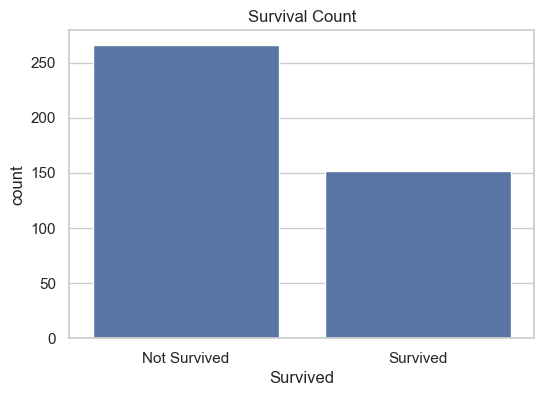

In [14]:
# Plot 1: Survival count
plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df_viz)
plt.title("Survival Count")
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()

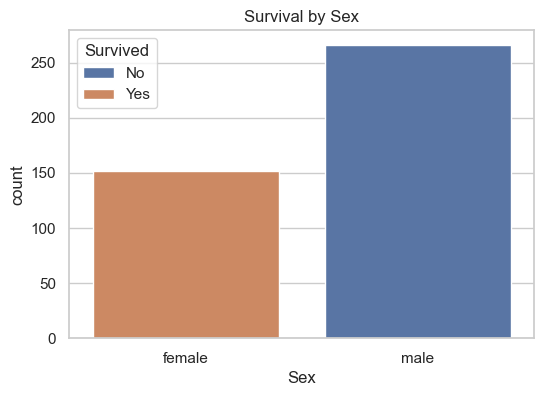

In [15]:
# Plot 2: Survival by Sex
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=df_viz)
plt.title("Survival by Sex")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

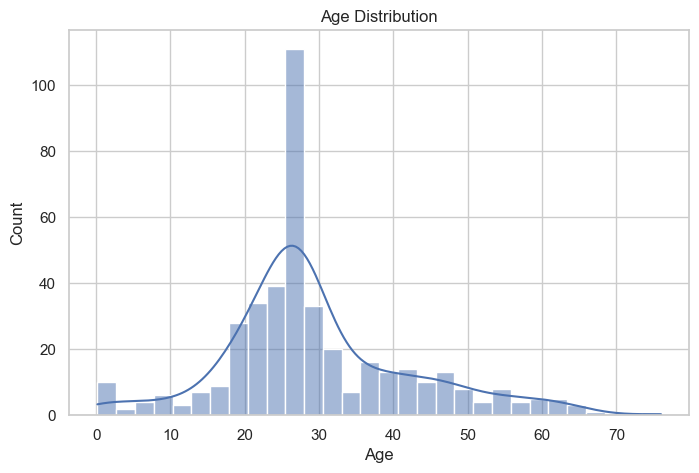

In [16]:
# Plot 3: Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_viz["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

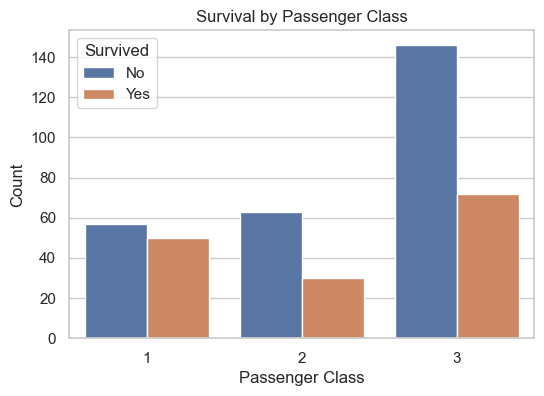

In [17]:
# Plot 4: Pclass vs Survival
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=df_viz)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

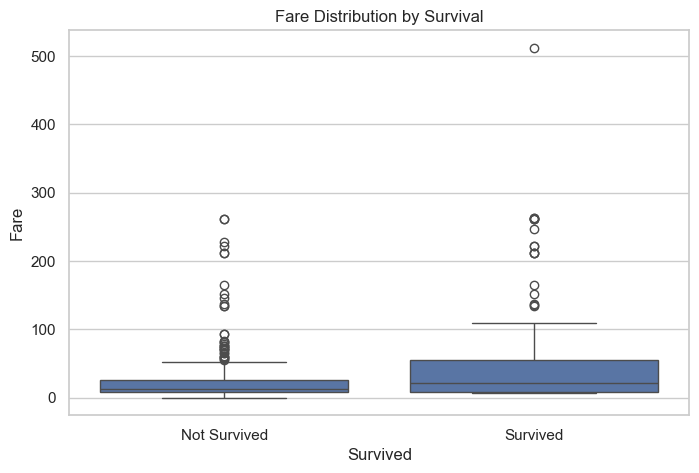

In [18]:
# Plot 5: Fare distribution by Survival
plt.figure(figsize=(8, 5))
sns.boxplot(x="Survived", y="Fare", data=df_viz)
plt.title("Fare Distribution by Survival")
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()

#### Feature Engineering

In [19]:
# Copy to avoid modifying the original
df_fe = df.copy()

In [20]:
#Fill missing values
df_fe['Age'].fillna(df_fe['Age'].median(), inplace=True)
df_fe['Fare'].fillna(df_fe['Fare'].median(), inplace=True)
df_fe['Embarked'].fillna(df_fe['Embarked'].mode()[0], inplace=True)

In [21]:
#Create FamilySize = SibSp + Parch + 1
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1

#Create IsAlone = 1 if FamilySize == 1, else 0
df_fe['IsAlone'] = (df_fe['FamilySize'] == 1).astype(int)

#Convert Sex to numeric (male=0, female=1)
df_fe['Sex'] = df_fe['Sex'].map({'male': 0, 'female': 1})

In [22]:
#One-hot encode Embarked
df_fe = pd.get_dummies(df_fe, columns=['Embarked'], drop_first=True)

#Extract Title from Name
df_fe['Title'] = df_fe['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df_fe['Title'] = df_fe['Title'].replace(['Mlle', 'Ms'], 'Miss')
df_fe['Title'] = df_fe['Title'].replace(['Mme', 'Lady', 'Countess'], 'Mrs')
df_fe['Title'] = df_fe['Title'].replace(
    ['Dr', 'Major', 'Col', 'Rev', 'Sir', 'Don', 'Jonkheer', 'Capt'],
    'Rare'
)
df_fe['Title'] = df_fe['Title'].fillna('Unknown')

In [23]:
#One-hot encode Title
df_fe = pd.get_dummies(df_fe, columns=['Title'], drop_first=True)

#Drop unnecessary columns
df_fe.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'], inplace=True)

# Display first few rows
print(df_fe.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0         0       3    0  34.5      0      0   7.8292           1        1   
1         1       3    1  47.0      1      0   7.0000           2        0   
2         0       2    0  62.0      0      0   9.6875           1        1   
3         0       3    0  27.0      0      0   8.6625           1        1   
4         1       3    1  22.0      1      1  12.2875           3        0   

   Embarked_Q  Embarked_S  Title_Master  Title_Miss  Title_Mr  Title_Mrs  \
0        True       False         False       False      True      False   
1       False        True         False       False     False       True   
2        True       False         False       False      True      False   
3       False        True         False       False      True      False   
4       False        True         False       False     False       True   

   Title_Rare  
0       False  
1       False  
2       False  
3       Fa

#### Model Building

### Random Forest

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [25]:
#Assuming df is your DataFrame (loaded Titanic dataset)
titanic_data = df.dropna(subset=['Survived'])

# Features and target variable
X = titanic_data[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = titanic_data['Survived']


In [26]:
# Encode 'Sex' column
X.loc[:, 'Sex'] = X['Sex'].map({'female': 0, 'male': 1})

# Fill missing 'Age' values with the median
X.loc[:, 'Age'].fillna(X['Age'].median(), inplace=True)

In [27]:
# Optional: Scaling the features
scaler = StandardScaler()
X[['Age', 'Fare', 'SibSp', 'Parch']] = scaler.fit_transform(X[['Age', 'Fare', 'SibSp', 'Parch']])



In [28]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)



RandomForestClassifier()

In [29]:
# Train a Random Forest model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)


In [30]:
# Sample prediction
sample = X_test.iloc[0:1]  # Keep as DataFrame to match model input format
prediction = rf_classifier.predict(sample)

# Retrieve and display the sample
sample_dict = sample.iloc[0].to_dict()
print(f"\nSample Passenger: {sample_dict}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did Not Survive'}")


Sample Passenger: {'Pclass': 3, 'Sex': 1, 'Age': -0.3624745864489434, 'SibSp': -0.49947001653571804, 'Parch': -0.40024770163856355, 'Fare': -0.508555407729792}
Predicted Survival: Did Not Survive


#### Model deployment

In [31]:
import joblib

joblib.dump(model, "titanic_model.pkl")


print("Model saved successfully!")


Model saved successfully!
